# Task 1: Analysis of Symptom Co-Occurrence Patterns using Apriori Algorithm -- General Analysis

Given that the explorations of a disease-specific apriori analysis for frequent itemsets failed to yield interesting findings due to a highly uniform dataset, we set out to discover rules from a non-disease-specific standpoint. The main aim is as follows:

1. To discover, regardless of diseases, the frequent itemsets that appear among all entries of symptoms. What symptoms appear together? What rules can we discover?
2. What are some ways we can visualise the relationships across frequent itemsets? Are there symptoms that occur frequently in multiple distinct itemsets?
3. How can we obtain useful findings when frequent itemsets may be similar to each other? 

## 1.1 Setup and Imports

In [23]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from apriori_miner import AprioriMiner

## 1.2 Helper Functions

In [24]:
def clean_disease_data(df):
    """
    Basic cleaning: whitespace, empty strings, basic formatting.
    """
    df = df.copy()
    # Remove whitespace
    string_cols = df.select_dtypes(include="object").columns
    for col in string_cols:
        df[col] = df[col].str.strip() if df[col].dtype == "object" else df[col]

    # Replace empty strings with NaN
    df = df.replace("", np.nan)

    # Lowercase and replace spaces with underscores
    symptom_cols = [col for col in df.columns if "Symptom" in col]
    for col in symptom_cols:
        df[col] = df[col].str.lower().str.replace(" _", "_").str.replace("_ ", "_")

    return df


def normalize_symptoms(df, normalization_dict):
    """
    Normalize symptoms using a mapping dictionary.
    """
    df = df.copy()

    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for col in symptom_cols:
        df[col] = df[col].map(
            lambda x: normalization_dict.get(x, x) if pd.notna(x) else x
        )

    return df


def merge_disease_symptoms(df):
    """
    Merge the disease symptoms
    """
    symptom_cols = [col for col in df.columns if "Symptom" in col]
    
    disease_symptoms = {}
    for _, row in df.iterrows():
        disease = row["Disease"]
        symptoms = [s for s in row[symptom_cols] if pd.notna(s)]
        
        if disease not in disease_symptoms:
            disease_symptoms[disease] = set()
        disease_symptoms[disease].update(symptoms)
    
    merged_data = []
    max_symptoms = max(len(syms) for syms in disease_symptoms.values())
    
    for disease, symptoms in disease_symptoms.items():
        symptoms_list = sorted(list(symptoms))
        row_dict = {"Disease": disease}
        
        for i, symptom in enumerate(symptoms_list, 1):
            row_dict[f"Symptom_{i}"] = symptom
        
        # Fill remaining columns with NaN
        for i in range(len(symptoms_list) + 1, max_symptoms + 1):
            row_dict[f"Symptom_{i}"] = np.nan
        
        merged_data.append(row_dict)
    
    df_merged = pd.DataFrame(merged_data)
    
    # Reorder columns
    cols = ["Disease"] + [f"Symptom_{i}" for i in range(1, max_symptoms + 1)]
    df_merged = df_merged[cols]
    
    return df_merged


def preprocess_disease_data(df, norm_dict):
    """Clean -> normalize -> merge"""
    df = clean_disease_data(df)
    df = normalize_symptoms(df, norm_dict)
    df = merge_disease_symptoms(df)
    return df


def convert_to_transactions(df):
    """
    Convert disease-symptom dataframe to transaction format for Apriori.

    Each disease becomes a transaction (basket) containing its symptoms (items).
    """
    transactions = []
    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for _, row in df.iterrows():
        # Collect non-null symptoms for this disease
        symptoms = [row[col] for col in symptom_cols if pd.notna(row[col])]

        # Only add if there are symptoms
        if symptoms:
            transactions.append(frozenset(symptoms))

    return transactions

## 1.3 Exploratory Data Analysis

In [ ]:
df_raw = pd.read_csv("../data/itachi9604_disease_symptom_description_dataset.csv")
print(f"Raw data shape: {df_raw.shape}")
display(df_raw.head())

Raw data shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
print(df_raw["Disease"].value_counts())

Disease
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
Aller

## 1.4 Data Preprocessing

In [27]:
SYMPTOM_NORMALIZATION = {
    # Spacing/formatting fixes
    "dischromic _patches": "dischromic_patches",
    "spotting_ urination": "spotting_urination",
    "foul_smell_of urine": "foul_smell_of_urine",
    # Typo fixes
    "cold_hands_and_feets": "cold_hands_and_feet",
    "scurring": "scarring",
    "swollen_extremeties": "swollen_extremities",
    # Pain location normalization
    "stomach_pain": "abdominal_pain",
    "belly_pain": "abdominal_pain",
}

In [28]:
df_final = preprocess_disease_data(df_raw, SYMPTOM_NORMALIZATION)
display(df_final)

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,dischromic_patches,itching,nodal_skin_eruptions,skin_rash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Allergy,chills,continuous_sneezing,shivering,watering_from_eyes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GERD,abdominal_pain,acidity,chest_pain,cough,ulcers_on_tongue,vomiting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Chronic cholestasis,abdominal_pain,itching,loss_of_appetite,nausea,vomiting,yellowing_of_eyes,yellowish_skin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Drug Reaction,abdominal_pain,burning_micturition,itching,skin_rash,spotting_urination,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Peptic ulcer diseae,abdominal_pain,indigestion,internal_itching,loss_of_appetite,passage_of_gases,vomiting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AIDS,extra_marital_contacts,high_fever,muscle_wasting,patches_in_throat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Diabetes,blurred_and_distorted_vision,excessive_hunger,fatigue,increased_appetite,irregular_sugar_level,lethargy,obesity,polyuria,restlessness,weight_loss,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Gastroenteritis,dehydration,diarrhoea,sunken_eyes,vomiting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Bronchial Asthma,breathlessness,cough,family_history,fatigue,high_fever,mucoid_sputum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.5 Apriori Algorithm

In [29]:
transactions = convert_to_transactions(df_final)

In [30]:
# Configuration
SUPPORT_VALUES = [0.05, 0.08, 0.1]
CONF_THRESHOLD = 0.7
LIFT_THRESHOLD = 1.5


In [31]:
def calculate_rule_metrics(association_rules):
    """Calculate average confidence, lift, and high-quality rule count."""
    if not association_rules:
        return 0, 0, 0
    rules_df = pd.DataFrame(association_rules)
    avg_conf = rules_df["confidence"].mean()
    avg_lift = rules_df["lift"].mean()
    high_quality = len(rules_df[(rules_df["confidence"] >= CONF_THRESHOLD) & (rules_df["lift"] >= LIFT_THRESHOLD)])
    return avg_conf, avg_lift, high_quality

def run_apriori_experiment(min_sup, transactions):
    """Run Apriori for a single min_support and return metrics."""
    miner = AprioriMiner(min_support=min_sup)
    miner.fit(transactions)
    miner.generate_rules(min_confidence=0.5)
    
    size_dist = {k: len(miner.frequent_itemsets.get(k, [])) for k in miner.frequent_itemsets.keys()}
    avg_conf, avg_lift, high_quality = calculate_rule_metrics(miner.association_rules)
    
    return {
        "min_support": min_sup,
        "min_support_count": int(min_sup * len(transactions)),
        "total_itemsets": len(miner.all_frequent_itemsets),
        "total_rules": len(miner.association_rules),
        "size_distribution": size_dist,
        "avg_confidence": avg_conf,
        "avg_lift": avg_lift,
        "high_quality_rules": high_quality,
    }


In [32]:
results = []
print("Testing different min_support values...\n")
for min_sup in SUPPORT_VALUES:
    result = run_apriori_experiment(min_sup, transactions)
    results.append(result)
    print(f"min_support = {min_sup} (≥{result['min_support_count']} diseases)")
    print(f"  Frequent itemsets: {result['total_itemsets']}")
    print(f"  Association rules: {result['total_rules']}")
    print(f"  High-quality rules: {result['high_quality_rules']}")
    if result['total_rules'] > 0:
        print(f"  Avg confidence: {result['avg_confidence']:.3f}")
        print(f"  Avg lift: {result['avg_lift']:.3f}")
    print("-" * 80)


Testing different min_support values...

Fitting Apriori with min_support=0.05 (count=3)
Total transactions: 41
Generating 1-itemsets...
  Found 31 frequent 1-itemsets
Generating 2-itemsets...
  Found 104 frequent 2-itemsets
Generating 3-itemsets...
  Found 153 frequent 3-itemsets
Generating 4-itemsets...
  Found 143 frequent 4-itemsets
Generating 5-itemsets...
  Found 86 frequent 5-itemsets
Generating 6-itemsets...
  Found 36 frequent 6-itemsets
Generating 7-itemsets...
  Found 9 frequent 7-itemsets
Generating 8-itemsets...
  Found 1 frequent 8-itemsets
Total frequent itemsets: 563

Generated 7741 association rules
  Min confidence: 0.5
  Min lift: 1.0
min_support = 0.05 (≥2 diseases)
  Frequent itemsets: 563
  Association rules: 7741
  High-quality rules: 5668
  Avg confidence: 0.827
  Avg lift: 7.683
--------------------------------------------------------------------------------
Fitting Apriori with min_support=0.08 (count=4)
Total transactions: 41
Generating 1-itemsets...
  Found 

In [33]:
comparison_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print(comparison_df[["min_support", "min_support_count", "total_itemsets", "total_rules", "avg_confidence", "avg_lift"]].to_string(index=False))



COMPARISON SUMMARY
 min_support  min_support_count  total_itemsets  total_rules  avg_confidence  avg_lift
        0.05                  2             563         7741        0.826870  7.682953
        0.08                  3             166          797        0.771646  4.655349
        0.10                  4              73          164        0.732762  3.552661


### Analysis of Apriori with Different Levels of $minsup$ Support

As min_support increases (0.05 → 0.10), we observe a trade-off between pattern rarity and reliability:

**Itemsets & Rules**: Stricter filtering removes rare symptom combinations exponentially. Losing itemsets causes rule count to drop faster than itemset count because each itemset generates multiple rules.

**Confidence & Lift**: Both decrease because we shift from rare, "pure" patterns to common, "mixed" patterns. 
Rare combinations have artificially high confidence and lift because they're exclusive—when they appear, they appear together. Common patterns are more realistic but weaker associations because frequent symptoms naturally co-occur with many others, reducing their predictive strength.

**Trade-off**: Lower min_support finds surprising but fragile patterns; higher min_support finds robust but mundane patterns.

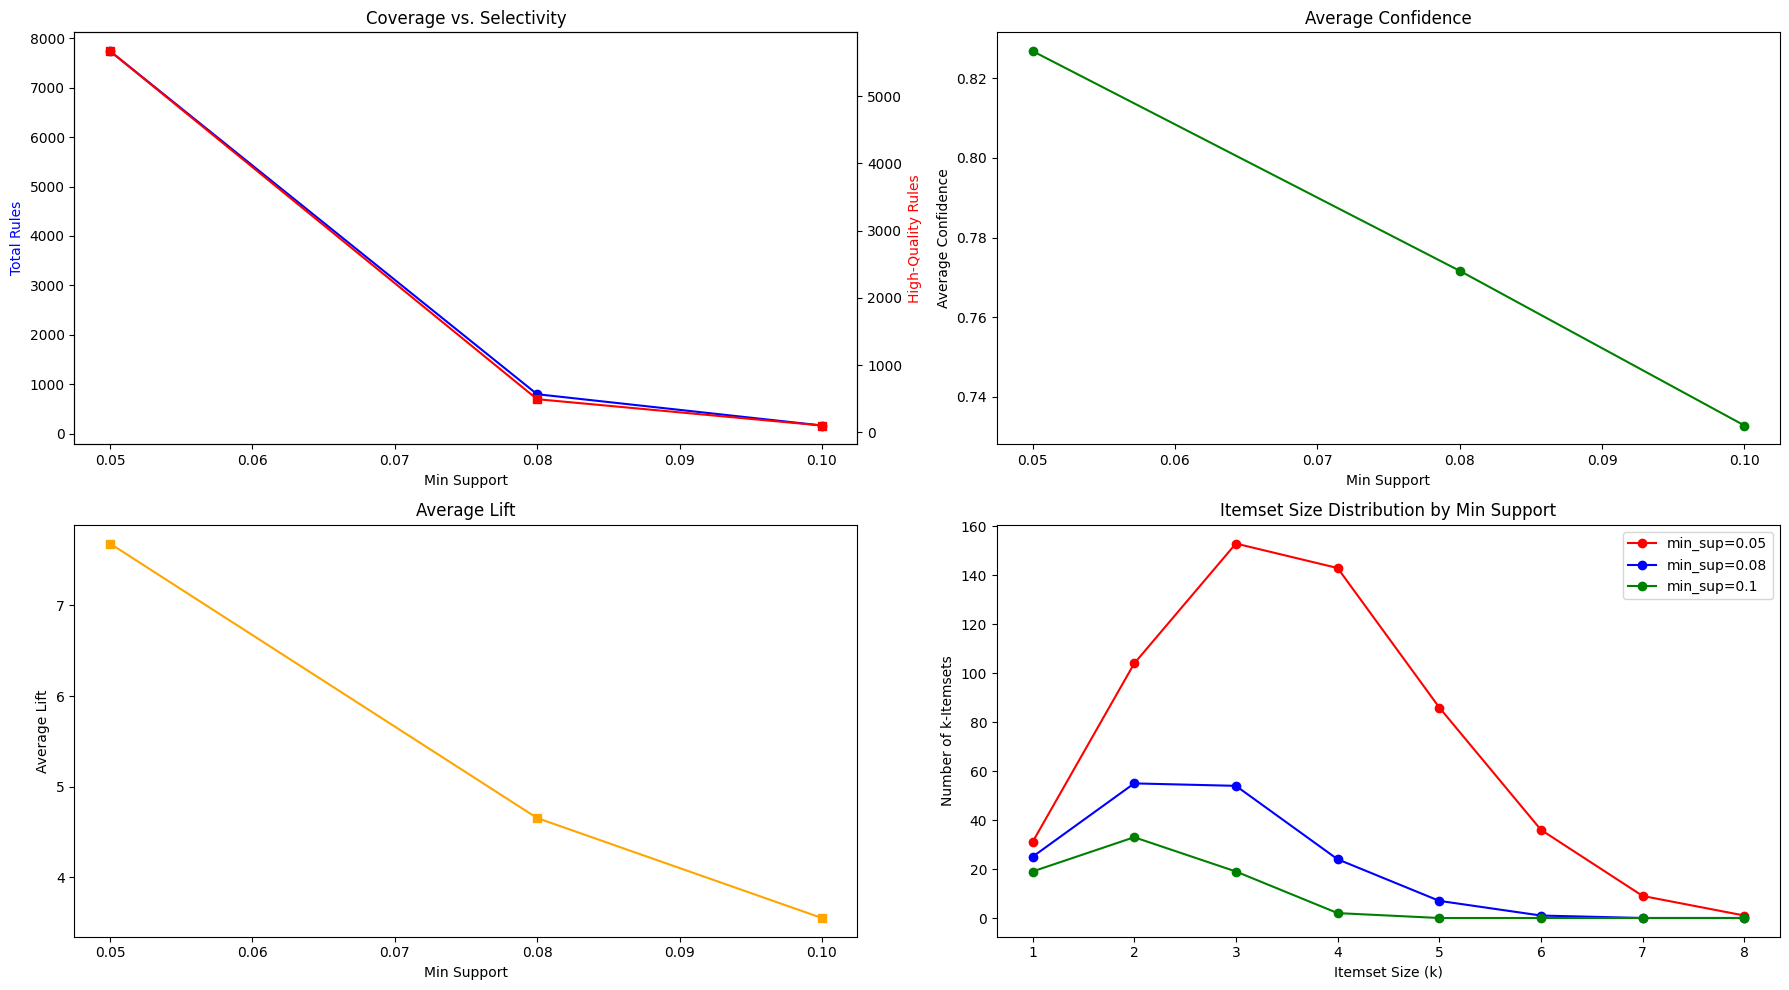

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: Trade-off between Coverage and Selectivity
ax1 = axes[0, 0]
ax1_twin = ax1.twinx()
line1 = ax1.plot(comparison_df["min_support"], comparison_df["total_rules"], "o-", color="blue", label="Total Rules")
line2 = ax1_twin.plot(comparison_df["min_support"], comparison_df["high_quality_rules"], "s-", color="red", label="High-Quality Rules")
ax1.set_xlabel("Min Support")
ax1.set_ylabel("Total Rules", color="blue")
ax1_twin.set_ylabel("High-Quality Rules", color="red")
ax1.set_title("Coverage vs. Selectivity")

# Plot 2a: Average Confidence
ax2a = axes[0, 1]
ax2a.plot(comparison_df["min_support"], comparison_df["avg_confidence"], "o-", color="green")
ax2a.set_xlabel("Min Support")
ax2a.set_ylabel("Average Confidence")
ax2a.set_title("Average Confidence")

# Plot 2b: Average Lift
ax2b = axes[1, 0]
ax2b.plot(comparison_df["min_support"], comparison_df["avg_lift"], "s-", color="orange")
ax2b.set_xlabel("Min Support")
ax2b.set_ylabel("Average Lift")
ax2b.set_title("Average Lift")

# Plot 3: Itemset Distribution
ax3 = axes[1, 1]
colors = ["red", "blue", "green", "orange", "purple", "brown"]
for idx, row in comparison_df.iterrows():
    min_sup = row["min_support"]
    sizes = [row["size_distribution"].get(k, 0) for k in range(1, 9)]
    ax3.plot(range(1, 9), sizes, "o-", color=colors[idx % len(colors)], label=f"min_sup={min_sup}")
ax3.set_xlabel("Itemset Size (k)")
ax3.set_ylabel("Number of k-Itemsets")
ax3.set_title("Itemset Size Distribution by Min Support")
ax3.legend()

plt.tight_layout()
plt.show()


## 1.6 Insights: Analyzing Strongest Association Rules

To continue, we choose a $minsup$ value of 0.08. 

At min_support = 0.08, we achieve a balance:

- Removes noise: Filters out rare, coincidental symptom combinations (those appearing in only 2 profiles)

- Retains meaningful patterns: Keeps robust associations that appear consistently (≥3 profiles)

- Manageable output: Generates 797 actionable rules—enough for analysis without overwhelming volume

- Quality over quantity: Maintains reasonable confidence (0.772) and lift (4.655) while eliminating correlating symptoms that occur by chance.

- Clinically relevant: Focus on symptom combinations occurring frequently enough to be significant

In [44]:
# Extract rules from min_support=0.08 experiment
min_sup_08_result = next(r for r in results if r["min_support"] == 0.08)

MINSUP = 0.08
MINCONF = 0.5
LIFT = 1.5

# Re-run the miner to get the actual rules
miner_08 = AprioriMiner(min_support=MINSUP)
miner_08.fit(transactions)
miner_08.generate_rules(min_confidence=MINCONF)

# Convert to DataFrame
rules_df = pd.DataFrame(miner_08.association_rules)

# Filter for strongest rules
strong_rules_df = rules_df[(rules_df["confidence"] >= 0.7) & (rules_df["lift"] >= LIFT)].copy()

# Add readable strings
strong_rules_df["antecedent_str"] = strong_rules_df["antecedent"].apply(lambda x: ", ".join(sorted(x)))
strong_rules_df["consequent_str"] = strong_rules_df["consequent"].apply(lambda x: ", ".join(sorted(x)))
strong_rules_df["rule_str"] = strong_rules_df["antecedent_str"] + " → " + strong_rules_df["consequent_str"]

print(f"Total rules at min_support={MINSUP}: {len(rules_df)}")
print(f"Strong rules (conf≥{MINCONF}, lift≥{LIFT}): {len(strong_rules_df)}")


Fitting Apriori with min_support=0.08 (count=4)
Total transactions: 41
Generating 1-itemsets...
  Found 25 frequent 1-itemsets
Generating 2-itemsets...
  Found 55 frequent 2-itemsets
Generating 3-itemsets...
  Found 54 frequent 3-itemsets
Generating 4-itemsets...
  Found 24 frequent 4-itemsets
Generating 5-itemsets...
  Found 7 frequent 5-itemsets
Generating 6-itemsets...
  Found 1 frequent 6-itemsets
Total frequent itemsets: 166

Generated 797 association rules
  Min confidence: 0.5
  Min lift: 1.0
Total rules at min_support=0.08: 797
Strong rules (conf≥0.5, lift≥1.5): 494


In [36]:
# Rank by confidence
top_confidence = strong_rules_df.nlargest(10, "confidence")[["rule_str", "support", "confidence", "lift"]]

# Rank by lift
top_lift = strong_rules_df.nlargest(10, "lift")[["rule_str", "support", "confidence", "lift"]]

# Rank by support
top_support = strong_rules_df.nlargest(10, "support")[["rule_str", "support", "confidence", "lift"]]

print("Top 10 Rules by Confidence:")
print(top_confidence.to_string(index=False))
print("\nTop 10 Rules by Lift:")
print(top_lift.to_string(index=False))
print("\nTop 10 Rules by Support:")
print(top_support.to_string(index=False))


Top 10 Rules by Confidence:
                                                                              rule_str  support  confidence  lift
abdominal_pain, loss_of_appetite, nausea → vomiting, yellowing_of_eyes, yellowish_skin 0.097561         1.0 10.25
abdominal_pain, nausea, yellowing_of_eyes → loss_of_appetite, vomiting, yellowish_skin 0.097561         1.0 10.25
loss_of_appetite, vomiting, yellowish_skin → abdominal_pain, nausea, yellowing_of_eyes 0.097561         1.0 10.25
vomiting, yellowing_of_eyes, yellowish_skin → abdominal_pain, loss_of_appetite, nausea 0.097561         1.0 10.25
                                  abdominal_pain, fatigue, yellowish_skin → dark_urine 0.097561         1.0  8.20
                      dark_urine, loss_of_appetite → abdominal_pain, yellowing_of_eyes 0.097561         1.0  8.20
                   loss_of_appetite, vomiting, yellowish_skin → abdominal_pain, nausea 0.097561         1.0  8.20
        loss_of_appetite, vomiting, yellowish_skin → abdomin

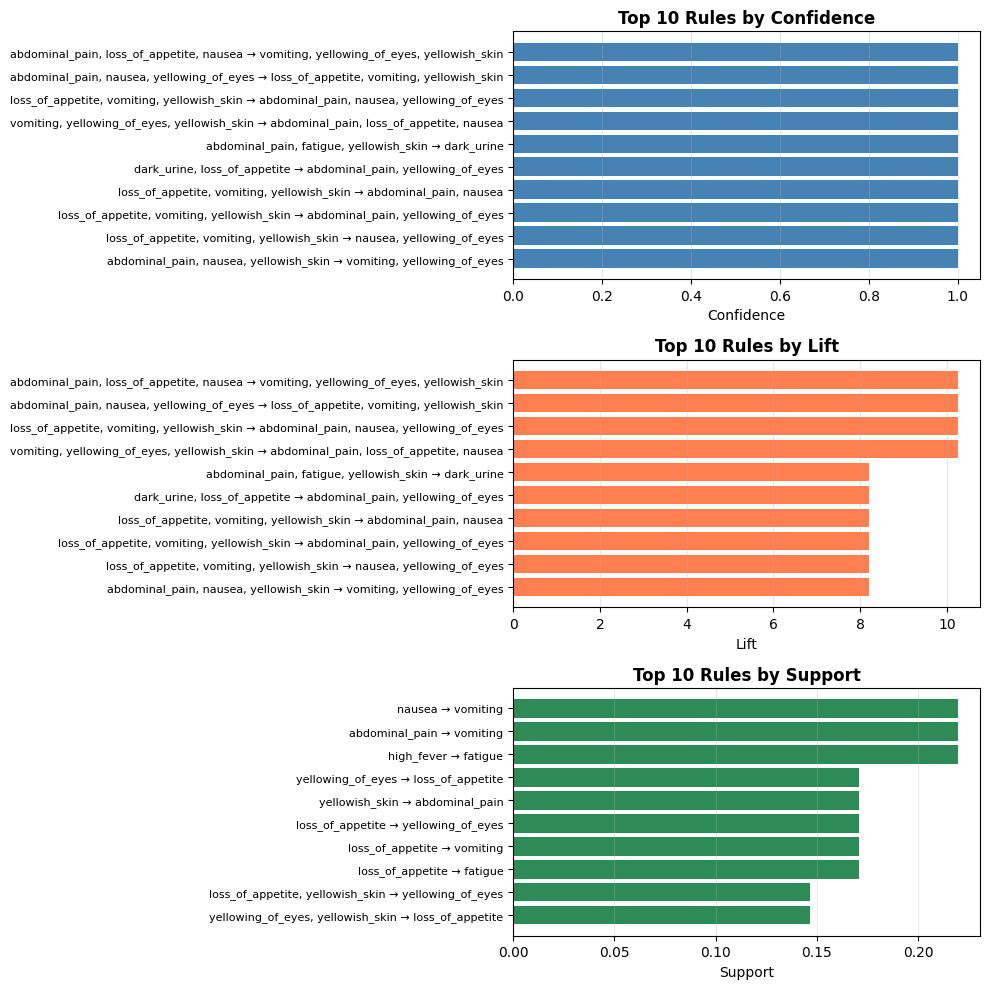

In [45]:
# Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Plot 1: Top by Confidence
axes[0].barh(
    range(len(top_confidence)),
    top_confidence["confidence"],
    color="steelblue"
)
axes[0].set_yticks(range(len(top_confidence)))
axes[0].set_yticklabels(top_confidence["rule_str"], fontsize=8)
axes[0].set_xlabel("Confidence", fontsize=10)
axes[0].set_title("Top 10 Rules by Confidence", fontsize=12, fontweight="bold")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

# Plot 2: Top by Lift
axes[1].barh(range(len(top_lift)), top_lift["lift"], color="coral")
axes[1].set_yticks(range(len(top_lift)))
axes[1].set_yticklabels(top_lift["rule_str"], fontsize=8)
axes[1].set_xlabel("Lift", fontsize=10)
axes[1].set_title("Top 10 Rules by Lift", fontsize=12, fontweight="bold")
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

# Plot 3: Top by Support
axes[2].barh(
    range(len(top_support)), top_support["support"], color="seagreen"
)
axes[2].set_yticks(range(len(top_support)))
axes[2].set_yticklabels(top_support["rule_str"], fontsize=8)
axes[2].set_xlabel("Support", fontsize=10)
axes[2].set_title("Top 10 Rules by Support", fontsize=12, fontweight="bold")
axes[2].invert_yaxis()
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Hierarchical Clustering -- Finding Common Clusters Among Symptoms

We observe distinct pattern groups among the frequent symptoms. 

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def extract_symptom_matrix(rules_df):
    """Convert rules to symptom co-occurrence matrix"""
    all_symptoms = set()
    
    for rule_str in rules_df['rule_str']:
        parts = rule_str.split(' → ')
        all_symptoms.update(s.strip() for s in parts[0].split(','))
        all_symptoms.update(s.strip() for s in parts[1].split(','))
    
    symptom_list = sorted(list(all_symptoms))
    # Add dtype=float here
    co_occurrence = pd.DataFrame(0.0, 
                                 index=symptom_list, 
                                 columns=symptom_list,
                                 dtype=float)
    
    for _, row in rules_df.iterrows():
        rule_str = row['rule_str']
        parts = rule_str.split(' → ')
        antecedent = set(s.strip() for s in parts[0].split(','))
        consequent = set(s.strip() for s in parts[1].split(','))
        all_symp = antecedent | consequent
        
        for s1 in all_symp:
            for s2 in all_symp:
                if s1 != s2:
                    co_occurrence.loc[s1, s2] += row['confidence']
    
    return co_occurrence, symptom_list

def cluster_symptoms(rules_df, n_clusters=3):
    """Hierarchical clustering of symptoms"""
    co_matrix, symptom_list = extract_symptom_matrix(rules_df)
    
    # Compute similarity
    similarity = cosine_similarity(co_matrix)
    distance = 1 - similarity
    
    # Cluster
    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='ward'
    )
    labels = clustering.fit_predict(distance)
    
    # Display results
    clusters = defaultdict(list)
    for symptom, label in zip(symptom_list, labels):
        clusters[label].append(symptom)
    
    for cluster_id, symptoms in clusters.items():
        print(f"\nCluster {cluster_id + 1}:")
        print(f"  {', '.join(symptoms)}")
    
    return clusters

# Usage
symptom_clusters = cluster_symptoms(strong_rules_df, n_clusters=4)


Cluster 1:
  abdominal_pain, dark_urine, fatigue, loss_of_appetite, nausea, vomiting, yellowing_of_eyes, yellowish_skin

Cluster 4:
  chest_pain

Cluster 3:
  chills, cough, headache, malaise

Cluster 2:
  diarrhoea, joint_pain

Cluster 5:
  high_fever, lethargy, weight_loss


### Problem: Repeated / Overlapping Baskets

All top rules involve the same 6-8 symptoms (abdominal_pain, loss_of_appetite, nausea, vomiting, yellowing_of_eyes, yellowish_skin, dark_urine). This indicates:
- These symptoms form a tightly coupled group that almost always co-occur
- Likely represents a specific disease profile
- Any subset of these symptoms strongly predicts the others

We try filtering for diversity below:

In [38]:
def get_diverse_top_k(rules_df, k=10, metric="lift", overlap_threshold=0.5):
    """
    Get top K diverse rules by avoiding symptom overlap.
    
    Parameters:
    - rules_df: DataFrame with association rules
    - k: Number of diverse rules to return
    - metric: Ranking metric ('lift', 'confidence', 'support')
    - overlap_threshold: Max Jaccard similarity allowed (0-1)
    """
    diverse_rules = []
    seen_symptom_sets = []
    
    # Sort by metric
    sorted_rules = rules_df.nlargest(len(rules_df), metric)
    
    for _, rule in sorted_rules.iterrows():
        current_symptoms = rule["antecedent"] | rule["consequent"]
        
        # Check overlap with already selected rules
        is_diverse = True
        for seen_set in seen_symptom_sets:
            # Calculate Jaccard similarity
            intersection = len(current_symptoms & seen_set)
            union = len(current_symptoms | seen_set)
            similarity = intersection / union if union > 0 else 0
            
            if similarity > overlap_threshold:
                is_diverse = False
                break
        
        if is_diverse:
            diverse_rules.append(rule)
            seen_symptom_sets.append(current_symptoms)
            
            if len(diverse_rules) >= k:
                break
    
    return pd.DataFrame(diverse_rules)


# Get diverse top 10 by each metric
print("=" * 80)
print("DIVERSE TOP 10 RULES (Max 10% symptom overlap allowed)")
print("=" * 80)

diverse_lift = get_diverse_top_k(
    strong_rules_df, k=10, metric="lift", overlap_threshold=0.1
)
print("\nTop 10 Diverse Rules by Lift:")
print(
    diverse_lift[["rule_str", "support", "confidence", "lift"]]
    .to_string(index=False)
)

diverse_confidence = get_diverse_top_k(
    strong_rules_df, k=10, metric="confidence", overlap_threshold=0.1
)
print("\n" + "=" * 80)
print("Top 10 Diverse Rules by Confidence:")
print(
    diverse_confidence[["rule_str", "support", "confidence", "lift"]]
    .to_string(index=False)
)

diverse_support = get_diverse_top_k(
    strong_rules_df, k=10, metric="support", overlap_threshold=0.1
)
print("\n" + "=" * 80)
print("Top 10 Diverse Rules by Support:")
print(
    diverse_support[["rule_str", "support", "confidence", "lift"]]
    .to_string(index=False)
)

DIVERSE TOP 10 RULES (Max 10% symptom overlap allowed)

Top 10 Diverse Rules by Lift:
                                                                              rule_str  support  confidence      lift
abdominal_pain, loss_of_appetite, nausea → vomiting, yellowing_of_eyes, yellowish_skin 0.097561         1.0 10.250000
                                                 chills, fatigue → high_fever, malaise 0.097561         0.8  6.560000
                                                                    cough → chest_pain 0.097561         0.8  5.466667

Top 10 Diverse Rules by Confidence:
                                                                              rule_str  support  confidence      lift
abdominal_pain, loss_of_appetite, nausea → vomiting, yellowing_of_eyes, yellowish_skin 0.097561         1.0 10.250000
                                                 chills, malaise → fatigue, high_fever 0.097561         1.0  4.555556
                                                   

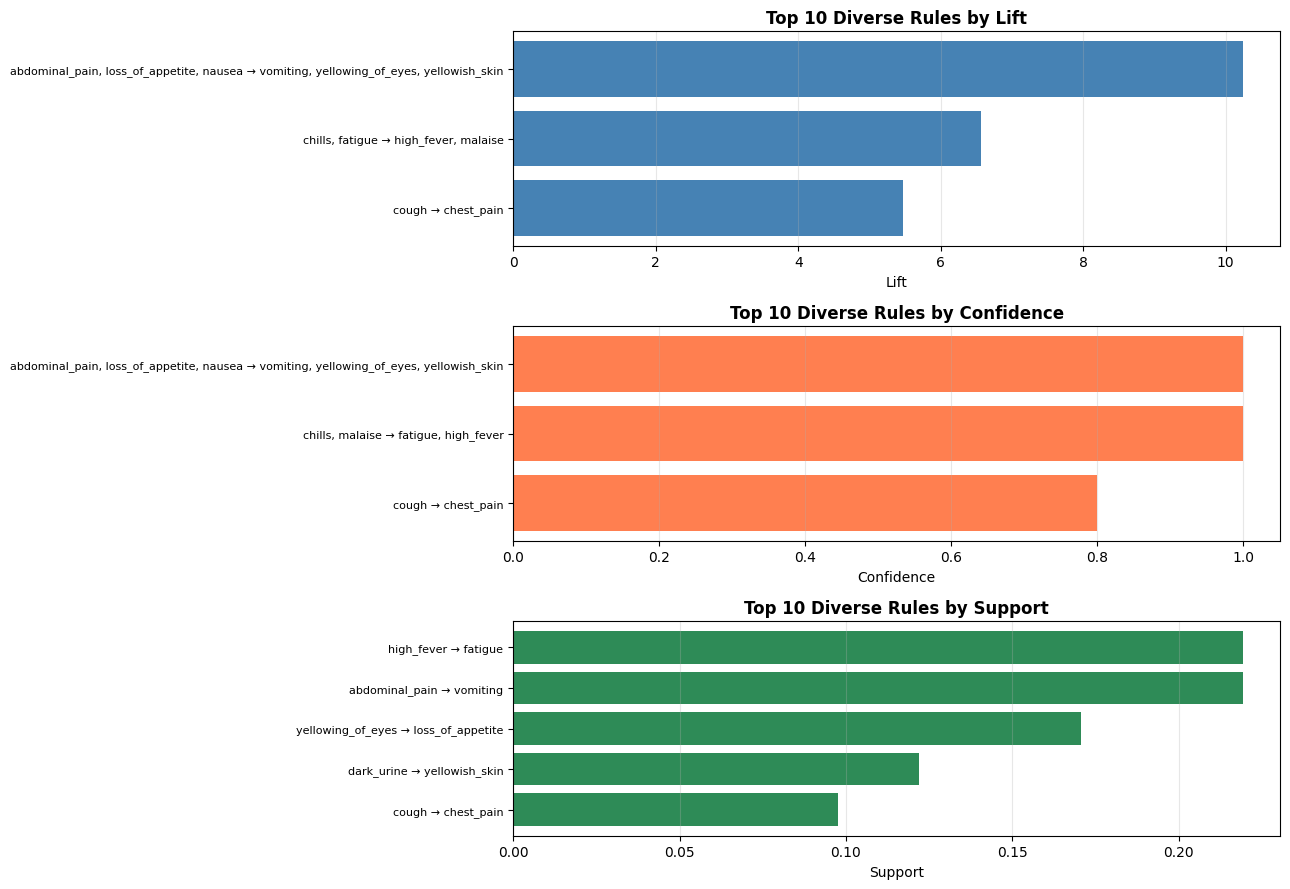


Diversity filtering removed 491 redundant rules from consideration.


In [39]:
# Visualize the diverse rules
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(13, 9))

# Plot 1: Diverse Lift
axes[0].barh(
    range(len(diverse_lift)),
    diverse_lift["lift"],
    color="steelblue"
)
axes[0].set_yticks(range(len(diverse_lift)))
axes[0].set_yticklabels(diverse_lift["rule_str"], fontsize=8)
axes[0].set_xlabel("Lift", fontsize=10)
axes[0].set_title(
    "Top 10 Diverse Rules by Lift",
    fontsize=12,
    fontweight="bold"
)
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)

# Plot 2: Diverse Confidence
axes[1].barh(
    range(len(diverse_confidence)),
    diverse_confidence["confidence"],
    color="coral"
)
axes[1].set_yticks(range(len(diverse_confidence)))
axes[1].set_yticklabels(diverse_confidence["rule_str"], fontsize=8)
axes[1].set_xlabel("Confidence", fontsize=10)
axes[1].set_title(
    "Top 10 Diverse Rules by Confidence",
    fontsize=12,
    fontweight="bold"
)
axes[1].invert_yaxis()
axes[1].grid(axis="x", alpha=0.3)

# Plot 3: Diverse Support
axes[2].barh(
    range(len(diverse_support)),
    diverse_support["support"],
    color="seagreen"
)
axes[2].set_yticks(range(len(diverse_support)))
axes[2].set_yticklabels(diverse_support["rule_str"], fontsize=8)
axes[2].set_xlabel("Support", fontsize=10)
axes[2].set_title(
    "Top 10 Diverse Rules by Support",
    fontsize=12,
    fontweight="bold"
)
axes[2].invert_yaxis()
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
# plt.savefig("diverse_top_rules.png", dpi=300, bbox_inches="tight")
plt.show()

print(
    f"\nDiversity filtering removed {len(strong_rules_df) - len(diverse_lift)} "
    f"redundant rules from consideration."
)

### 1.7 Symptom Association Network Graph

This directed network graph visualizes the relationships between symptoms
based on discovered association rules, focusing on the 15 most connected
symptoms in the dataset.

**Network components:**
- **Nodes (circles):** Individual symptoms
- **Edges (arrows):** Association rules, pointing from antecedent → consequent
- **Node size:** Proportional to degree centrality—larger nodes have more
  connections (appear in more rules)
- **Node color:** Degree centrality value (darker = higher connectivity)

**Degree centrality explained:**
Degree centrality measures how many direct connections a symptom has. A high
degree indicates a "hub" symptom that frequently appears in association rules,
either as:
- **High out-degree:** Strong predictor of other symptoms (many outgoing arrows)
- **High in-degree:** Common consequent, often co-occurring with various
  symptoms (many incoming arrows)

**Layout:**
The Kamada-Kawai layout optimally positions nodes based on graph-theoretic
distance, placing highly connected symptoms near the center and less connected
ones at the periphery.

**Key insights:**
- **Central, large nodes:** Core symptoms that serve as key indicators across
  multiple disease profiles
- **Edge clustering:** Groups of symptoms with strong mutual associations,
  potentially indicating symptom complexes
- **Peripheral nodes:** Specialized symptoms with fewer but potentially stronger
  specific associations

This visualization helps identify which symptoms are most "influential" in the
co-occurrence network and reveals potential symptom clusters for further
investigation.

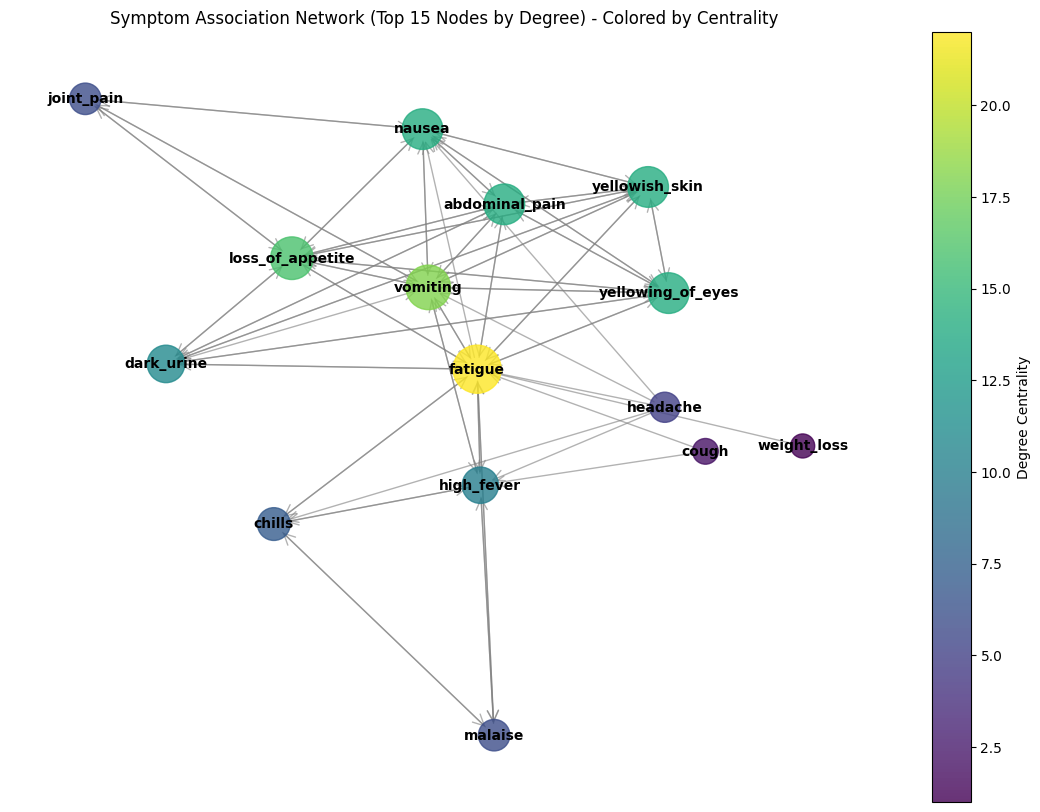

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

# Create the network graph
G = nx.DiGraph()
for _, row in strong_rules_df.iterrows():
    for ant in row["antecedent"]:
        for cons in row["consequent"]:
            G.add_edge(ant, cons, weight=row["lift"])
            
node_count = 15

# Select top 20 nodes by degree for readability
top_nodes = sorted(G.nodes, key=lambda x: G.degree(x), reverse=True)[:node_count]
subG = G.subgraph(top_nodes)

# Calculate degree centrality
degrees = dict(subG.degree())
degree_values = list(degrees.values())

# Scale node sizes: min 300, max 1200
min_size, max_size = 300, 1200
node_sizes = [min_size + (deg - min(degree_values)) / (max(degree_values) - min(degree_values)) * (max_size - min_size) if max(degree_values) > min(degree_values) else min_size for deg in degree_values]

# Use Kamada-Kawai layout for better spacing
plt.figure(figsize=(14, 10))
pos = nx.kamada_kawai_layout(subG)

# Draw nodes with color based on degree
nodes = nx.draw_networkx_nodes(subG, pos, node_size=node_sizes, node_color=degree_values, cmap=plt.cm.viridis, alpha=0.8)
nx.draw_networkx_edges(subG, pos, edge_color="gray", arrows=True, arrowstyle="->", arrowsize=20, alpha=0.6)
nx.draw_networkx_labels(subG, pos, font_size=10, font_weight="bold")

# Add colorbar
cbar = plt.colorbar(nodes, ax=plt.gca())
cbar.set_label("Degree Centrality")

plt.title(f"Symptom Association Network (Top {node_count} Nodes by Degree) - Colored by Centrality")
plt.axis("off")
plt.show()


### 1.8. Symptom Frequency Distribution

This section visualizes how frequently each symptom appears across diseases, identifying common "hub" symptoms (e.g., fever, fatigue) that may indicate broad conditions versus specific ones.

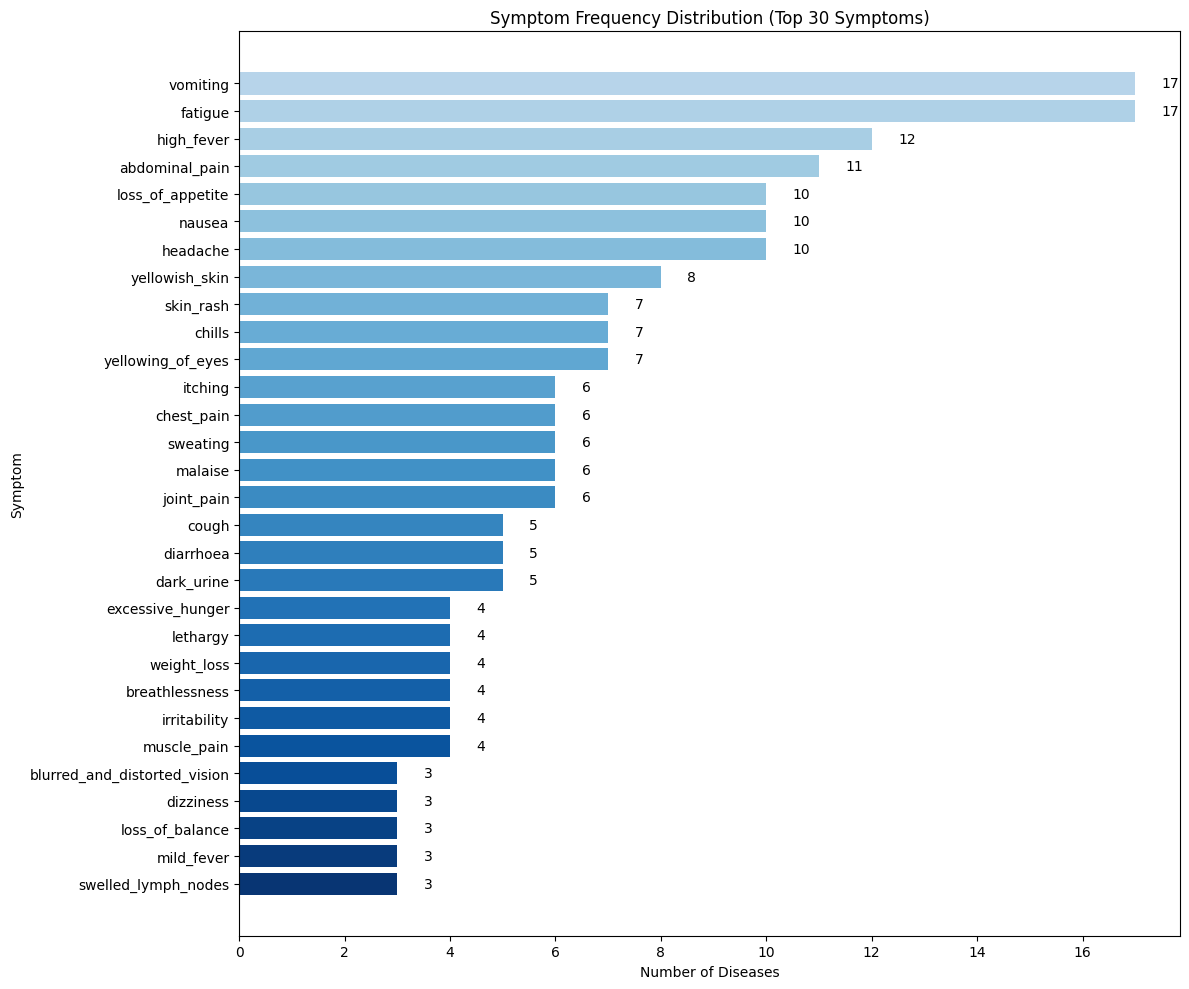

Hub Symptoms (most common): vomiting, fatigue, high_fever, abdominal_pain, loss_of_appetite
Total unique symptoms: 129
Symptoms appearing in only 1 disease: 79


In [41]:
from collections import Counter
import matplotlib.pyplot as plt

# Flatten all symptoms from df_final
all_symptoms = []
symptom_cols = [col for col in df_final.columns if "Symptom" in col]
for _, row in df_final.iterrows():
    for col in symptom_cols:
        symptom = row[col]
        if pd.notna(symptom):
            all_symptoms.append(symptom)

# Count frequencies
symptom_counts = Counter(all_symptoms)

# Sort and select top 30 for readability
top_symptoms = dict(sorted(symptom_counts.items(), key=lambda x: x[1], reverse=True)[:30])

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
bars = ax.barh(list(top_symptoms.keys()), list(top_symptoms.values()), color=plt.cm.Blues([0.3 + 0.7 * (i / len(top_symptoms)) for i in range(len(top_symptoms))]))
ax.set_xlabel("Number of Diseases")
ax.set_ylabel("Symptom")
ax.set_title("Symptom Frequency Distribution (Top 30 Symptoms)")
ax.invert_yaxis()  # Highest at top

# Add counts on bars
for bar, count in zip(bars, top_symptoms.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{count}', ha='left', va='center')

# Log scale if skewed
if max(top_symptoms.values()) / min([v for v in top_symptoms.values() if v > 0]) > 10:
    ax.set_xscale('log')
    ax.set_xlabel("Number of Diseases (Log Scale)")

plt.tight_layout()
plt.show()

# Print insights
hub_symptoms = list(top_symptoms.keys())[:5]
print(f"Hub Symptoms (most common): {', '.join(hub_symptoms)}")
print(f"Total unique symptoms: {len(symptom_counts)}")
print(f"Symptoms appearing in only 1 disease: {sum(1 for count in symptom_counts.values() if count == 1)}")


### 1.9. Antecedent Size Distribution

This section shows the distribution of antecedent sizes in strong rules, indicating if associations are based on single symptoms or combinations.

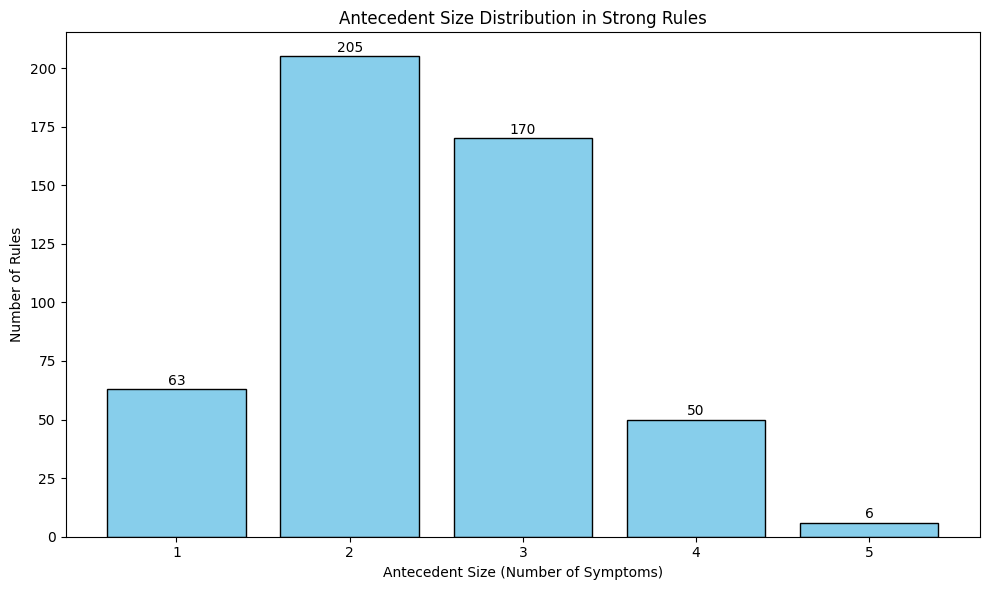

Total strong rules: 494
Rules with 1-item antecedents (simple): 63 (12.8%)
Rules with >1-item antecedents (complex): 431 (87.2%)
Average antecedent size for complex rules: 2.7


In [42]:
import matplotlib.pyplot as plt
from collections import Counter

# Compute antecedent sizes
antecedent_sizes = [len(row["antecedent"]) for _, row in strong_rules_df.iterrows()]
size_counts = Counter(antecedent_sizes)

# Sort by size
sorted_sizes = sorted(size_counts.keys())
counts = [size_counts[k] for k in sorted_sizes]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(sorted_sizes, counts, color='skyblue', edgecolor='black')
ax.set_xlabel("Antecedent Size (Number of Symptoms)")
ax.set_ylabel("Number of Rules")
ax.set_title("Antecedent Size Distribution in Strong Rules")
ax.set_xticks(sorted_sizes)

# Add counts on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{count}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print insights
total_rules = len(strong_rules_df)
simple_rules = size_counts.get(1, 0)
complex_rules = total_rules - simple_rules
print(f"Total strong rules: {total_rules}")
print(f"Rules with 1-item antecedents (simple): {simple_rules} ({simple_rules/total_rules*100:.1f}%)")
print(f"Rules with >1-item antecedents (complex): {complex_rules} ({complex_rules/total_rules*100:.1f}%)")
if complex_rules > 0:
    avg_complex_size = sum(k * size_counts[k] for k in size_counts if k > 1) / complex_rules
    print(f"Average antecedent size for complex rules: {avg_complex_size:.1f}")


### 1.10. Sankey Diagram (Symptom Flow Diagram)

This Sankey diagram visualizes the top 20 association rules ranked by lift
value. Each node represents a symptom, and each flow (link) represents a
discovered association rule.

**How to interpret:**
- **Flow direction:** Left symptom(s) → Right symptom(s) indicates the
  association rule antecedent → consequent
- **Flow thickness:** Proportional to the lift value—thicker flows indicate
  stronger associations between symptom pairs
- **Node size:** Represents the symptom's involvement across multiple
  rules—larger nodes appear in more high-lift associations

**Key insights:**
- Symptoms appearing as large nodes on the right are common consequents
  (frequently co-occurring with other symptoms)
- Symptoms with multiple outgoing flows are strong predictors of other symptoms
- Clustered flows between specific symptom pairs indicate particularly strong
  co-occurrence patterns worth clinical investigation

This visualization helps identify "hub" symptoms that serve as key indicators
for multiple other symptoms, useful for differential diagnosis and understanding
disease symptom profiles.

In [43]:
import plotly.graph_objects as go

# Prepare top 20 rules
top_rules = strong_rules_df.nlargest(5, "lift").copy()

# Create source-target pairs
sources = []
targets = []
values = []
labels = set()

for _, row in top_rules.iterrows():
    for ant in row["antecedent"]:
        for cons in row["consequent"]:
            sources.append(ant)
            targets.append(cons)
            values.append(row["lift"])
            labels.add(ant)
            labels.add(cons)

# Map symptoms to indices
labels = list(labels)
label_map = {label: i for i, label in enumerate(labels)}

source_idx = [label_map[s] for s in sources]
target_idx = [label_map[t] for t in targets]

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(
        source=source_idx,
        target=target_idx,
        value=values,
        color="rgba(0,0,255,0.2)"
    )
)])
fig.update_layout(
    title="Symptom Association Flow (Top Rules by Lift)",
    height=600
)
fig.show()